# Baselines + Validation Strategy

In [2]:
# Imports + Load + Preprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from src.preprocessing import PreprocessConfig, preprocess_train_test

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 180)

TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH  = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

cfg = PreprocessConfig(id_col="ID", target_col="Target")

train, test = preprocess_train_test(train_raw, test_raw, cfg, for_model="lightgbm")  # fill missing categoricals with "missing"
TARGET = cfg.target_col
ID = cfg.id_col

print("train:", train.shape, "| test:", test.shape)
train[[ID, TARGET]].head()

train: (9618, 47) | test: (2405, 46)


,ID,Target
0,ID_3CFL0U,Low
1,ID_XWI7G3,Medium
2,ID_TY93LV,Low
3,ID_9OP2C8,Low
4,ID_13REYS,Low


In [3]:
# Prepare X/y and identify feature types

y = train[TARGET]
X = train.drop(columns=[TARGET])

#Identify categorical columns/strings and numeric columns
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("categorical columns:", len(cat_cols))
print("numeric columns:", len(num_cols))
print("example categorical columns:", cat_cols[:10])
print("example numeric columns:", num_cols[:10])

categorical columns: 32
numeric columns: 14
example categorical columns: ['ID', 'country', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow']
example numeric columns: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months', 'personal_income_missing', 'business_expenses_missing', 'business_turnover_missing', 'log_personal_income']


## 1) Validation strategy

**We will implement two validation schemes and report both.**

✅ Scheme 1: StratifiedKFold (main CV)

✅ Scheme 2: Group-based diagnostic by country

✅ Scheme 3: Leave-One-Country-Out stress test

In [4]:
# Define evaluation helpers (reusable functions)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

def run_cv(model, X, y, cv_splits, fit_params=None, verbose=False):
    """
    Generic CV runner: fits model on each split, evaluates macro F1.
    """
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv_splits, 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        if fit_params is None:
            model.fit(X_tr, y_tr)
        else:
            model.fit(X_tr, y_tr, **fit_params)

        pred = model.predict(X_va)
        score = macro_f1(y_va, pred)
        scores.append(score)

        if verbose:
            print(f"Fold {fold}: macro F1 = {score:.4f}")

    return np.mean(scores), np.std(scores), scores

In [5]:
# Validation scheme 1: StratifiedKFold (main).
# Keeps class proportions balanced in each fold.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_splits = list(skf.split(X, y))

print("StratifiedKFold splits:", len(skf_splits))

StratifiedKFold splits: 5


In [6]:
# Validation scheme 2: GroupKFold by country (diagnostic)
# checks if our model generalizes across countries.

if "country" in X.columns:
    groups = X["country"]
    gkf = GroupKFold(n_splits=4)  # 4 countries -> 4 folds (each fold leaves out one country)
    gkf_splits = list(gkf.split(X, y, groups=groups))
    print("GroupKFold splits:", len(gkf_splits))
else:
    gkf_splits = None
    print("No country column found; skipping GroupKFold.")

GroupKFold splits: 4


In [7]:
# Validation scheme 3: Leave-One-Country-Out (LOCO) stress test
# basically the same idea as GroupKFold but we explicitly report performance per held-out country.


def leave_one_country_out_splits(X, y, country_col="country"):
    splits = []
    for c in sorted(X[country_col].dropna().unique()):
        va_idx = X.index[X[country_col] == c].to_numpy()
        tr_idx = X.index[X[country_col] != c].to_numpy()
        splits.append((tr_idx, va_idx, c))
    return splits

loco_splits = None
if "country" in X.columns:
    loco_splits = leave_one_country_out_splits(X, y, "country")
    print("LOCO folds:", len(loco_splits))

LOCO folds: 4


## 2) Baselines

We will build:

- Baseline A: Majority class

- Baseline B: Logistic Regression (OneHotEncoder)

- Baseline C: ExtraTrees (or RandomForest)

And produce A results table comparing CV scores under StratifiedKFold and GroupKFold.

In [8]:
# Baseline A — Majority Class (sanity check)

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent", random_state=42)

mean_f1, std_f1, _ = run_cv(dummy, X, y, skf_splits, verbose=False)
print(f"Dummy (Most Frequent) - StratifiedKFold macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

if gkf_splits is not None:
    mean_f1_g, std_f1_g, _ = run_cv(dummy, X, y, gkf_splits, verbose=False)
    print(f"Dummy (Most Frequent) - GroupKFold macro F1: {mean_f1_g:.4f} ± {std_f1_g:.4f}")

Dummy (Most Frequent) - StratifiedKFold macro F1: 0.2633 ± 0.0000
Dummy (Most Frequent) - GroupKFold macro F1: 0.2619 ± 0.0266


In [10]:
# Baseline B — Logistic Regression (OneHotEncoder)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scale data
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # with_mean=False keeps compatibility with sparse matrices
])

# Preprocess for logistic regression
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
])

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, cat_cols),
        ("num", num_transformer, num_cols)
    ],
    remainder="drop"
)

logreg = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    solver="saga",
    C=0.5   # smaller C => stronger regularization
)

logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

mean_f1, std_f1, _ = run_cv(logreg_model, X, y, skf_splits)
print(f"LogReg (OHE) - StratifiedKFold macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

if gkf_splits is not None:
    mean_f1_g, std_f1_g, _ = run_cv(logreg_model, X, y, gkf_splits)
    print(f"LogReg (OHE) - GroupKFold macro F1: {mean_f1_g:.4f} ± {std_f1_g:.4f}")

LogReg (OHE) - StratifiedKFold macro F1: 0.0922 ± 0.0307
LogReg (OHE) - GroupKFold macro F1: 0.0635 ± 0.0306


Linear models performed poorly under proper convergence `(macro F1 ≈ 0.09)`, indicating strong nonlinear interactions and complex feature relationships. This motivated the use of tree-based ensemble models better suited to high-cardinality categorical data.

In [11]:
# Baseline C — ExtraTrees (fast & strong tree baseline)

from sklearn.ensemble import ExtraTreesClassifier

# For tree models, we need numeric-only features.
# We'll encode categoricals as integer codes (simple baseline).
X_tree = X.copy()

for c in cat_cols:
    X_tree[c] = X_tree[c].astype("category").cat.codes

# Replace -1 codes (NaN category) with -1 explicitly
X_tree[cat_cols] = X_tree[cat_cols].replace(-1, -1)

et = ExtraTreesClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    class_weight="balanced_subsample"
)

mean_f1, std_f1, _ = run_cv(et, X_tree, y, skf_splits)
print(f"ExtraTrees - StratifiedKFold macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

if gkf_splits is not None:
    mean_f1_g, std_f1_g, _ = run_cv(et, X_tree, y, gkf_splits)
    print(f"ExtraTrees - GroupKFold macro F1: {mean_f1_g:.4f} ± {std_f1_g:.4f}")

ExtraTrees - StratifiedKFold macro F1: 0.7790 ± 0.0168
ExtraTrees - GroupKFold macro F1: 0.4086 ± 0.1555


ExtraTrees achieved strong performance under stratified CV `(macro F1 ≈ 0.78)`, demonstrating substantial nonlinear signal in the features. However, performance dropped significantly under country-grouped validation `(macro F1 ≈ 0.41)`, revealing strong country-specific patterns and potential domain shift. This highlights the importance of group-aware validation and motivates further modeling with algorithms that better capture robust cross-country structure.

In [12]:
# Produce a baseline results table

results = []

def add_result(name, mean_s, std_s, mean_g=None, std_g=None):
    results.append({
        "model": name,
        "StratifiedKFold_F1_mean": round(mean_s, 4),
        "StratifiedKFold_F1_std": round(std_s, 4),
        "GroupKFold_F1_mean": None if mean_g is None else round(mean_g, 4),
        "GroupKFold_F1_std": None if std_g is None else round(std_g, 4),
    })

# Dummy
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
m_s, s_s, _ = run_cv(dummy, X, y, skf_splits)
if gkf_splits is not None:
    m_g, s_g, _ = run_cv(dummy, X, y, gkf_splits)
    add_result("Dummy (most frequent)", m_s, s_s, m_g, s_g)
else:
    add_result("Dummy (most frequent)", m_s, s_s)

# LogReg
m_s, s_s, _ = run_cv(logreg_model, X, y, skf_splits)
if gkf_splits is not None:
    m_g, s_g, _ = run_cv(logreg_model, X, y, gkf_splits)
    add_result("LogReg + OHE", m_s, s_s, m_g, s_g)
else:
    add_result("LogReg + OHE", m_s, s_s)

# ExtraTrees
m_s, s_s, _ = run_cv(et, X_tree, y, skf_splits)
if gkf_splits is not None:
    m_g, s_g, _ = run_cv(et, X_tree, y, gkf_splits)
    add_result("ExtraTrees (cat codes)", m_s, s_s, m_g, s_g)
else:
    add_result("ExtraTrees (cat codes)", m_s, s_s)

results_df = pd.DataFrame(results).sort_values("StratifiedKFold_F1_mean", ascending=False)
display(results_df)

,model,StratifiedKFold_F1_mean,StratifiedKFold_F1_std,GroupKFold_F1_mean,GroupKFold_F1_std
2,ExtraTrees (cat codes),0.7790,0.0168,0.4086,0.1555
0,Dummy (most frequent),0.2633,0.0000,0.2619,0.0266
1,LogReg + OHE,0.0922,0.0307,0.0638,0.0303


ExtraTrees achieved strong macro-F1 under Stratified CV `(≈0.78)`, demonstrating significant nonlinear signal in the data. However, performance dropped to `≈0.41` under country-grouped validation, with high variance across folds. This indicates strong country-specific patterns and domain shift. The findings highlight the importance of group-aware validation and motivate the use of more robust categorical handling models such as `CatBoost`.

,held_out_country,macro_f1,n_val
3,zimbabwe,0.103366,2612
0,eswatini,0.081648,2674
1,lesotho,0.043222,1944
2,malawi,0.026835,2388


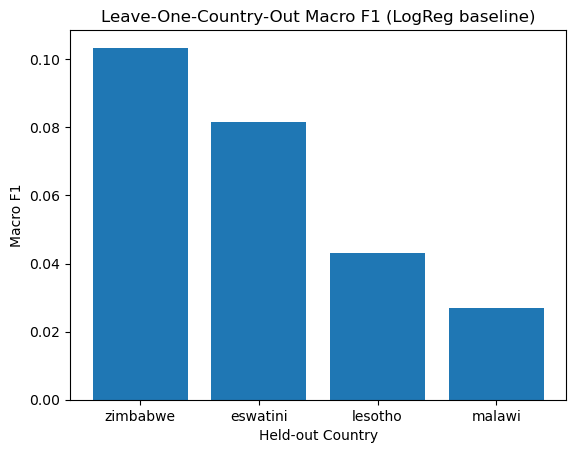

In [13]:
# LOCO (Leave-One-Country-Out) score breakdown

if loco_splits is not None:
    loco_rows = []
    for tr_idx, va_idx, held_out_country in loco_splits:
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        # Use your strongest baseline here (often LogReg or ExtraTrees)
        logreg_model.fit(X_tr, y_tr)
        pred = logreg_model.predict(X_va)
        score = macro_f1(y_va, pred)

        loco_rows.append({"held_out_country": held_out_country, "macro_f1": score, "n_val": len(va_idx)})

    loco_df = pd.DataFrame(loco_rows).sort_values("macro_f1", ascending=False)
    display(loco_df)

    plt.figure()
    plt.bar(loco_df["held_out_country"], loco_df["macro_f1"])
    plt.title("Leave-One-Country-Out Macro F1 (LogReg baseline)")
    plt.xlabel("Held-out Country")
    plt.ylabel("Macro F1")
    plt.show()

Leave-One-Country-Out evaluation revealed severe cross-country domain shift, with macro F1 dropping to `0.02–0.10` when an entire country was excluded from training. This demonstrates that SME financial health patterns are strongly country-conditioned. The findings emphasize the importance of group-aware validation and suggest that models must either incorporate robust cross-country interactions or be calibrated per country.

Macro F1: 0.11285454371060123
              precision    recall  f1-score   support

        High       0.05      0.88      0.09        94
         Low       0.72      0.12      0.21      1256
      Medium       0.31      0.02      0.03       574

    accuracy                           0.13      1924
   macro avg       0.36      0.34      0.11      1924
weighted avg       0.56      0.13      0.15      1924



,pred_High,pred_Low,pred_Medium
true_High,83,11,0
true_Low,1078,156,22
true_Medium,513,51,10


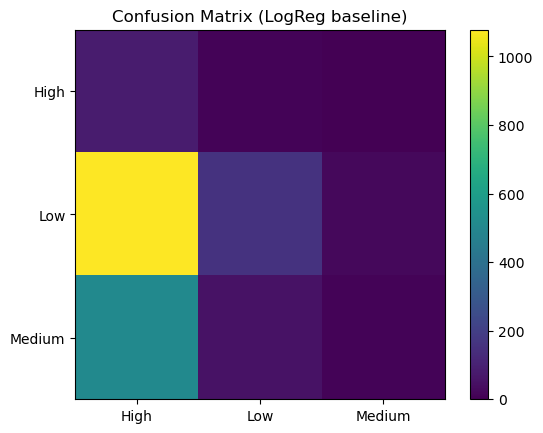

In [14]:
# Single-fold diagnostics: confusion matrix + classification report

# Pick one fold (fold 1) for detailed diagnostics
tr_idx, va_idx = skf_splits[0]
X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

logreg_model.fit(X_tr, y_tr)
pred = logreg_model.predict(X_va)

print("Macro F1:", macro_f1(y_va, pred))
print(classification_report(y_va, pred))

cm = confusion_matrix(y_va, pred, labels=sorted(y.unique()))
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in sorted(y.unique())],
                        columns=[f"pred_{c}" for c in sorted(y.unique())])
display(cm_df)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (LogReg baseline)")
plt.xticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.yticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.colorbar()
plt.show()

The logistic regression baseline exhibited severe class bias, heavily over-predicting the High class while nearly ignoring the Medium class. Macro F1 dropped to `~0.11` due to extremely poor recall for Medium `(0.02)`. The confusion matrix revealed systematic misclassification rather than random noise, indicating that the Financial Health Index classes are not linearly separable. These results confirm the necessity of nonlinear models capable of capturing complex interactions.

# Narrative — Baselines and Validation Strategy

## Objective

The objective of this notebook was to establish strong benchmarking baselines and evaluate model robustness under multiple validation strategies before proceeding to more advanced models.

The following models were evaluated:

- Dummy (Majority Class)
- Logistic Regression (One-Hot Encoding)
- ExtraTrees (Nonlinear Tree Ensemble)

Under two validation schemes:

- StratifiedKFold (standard cross-validation)
- GroupKFold by country (domain-shift diagnostic)

Additionally, a strict Leave-One-Country-Out (LOCO) evaluation was performed to assess cross-country generalization.

---

# 1. Baseline Performance Summary

| Model | Stratified Macro F1 | Group Macro F1 |
|-------|--------------------|---------------|
| ExtraTrees | 0.779 | 0.409 |
| Dummy | 0.263 | 0.262 |
| Logistic Regression | 0.092 | 0.064 |

## Key Observations

### Dummy Baseline

- Macro F1 ≈ 0.26 confirms class imbalance.
- Serves as a minimum performance benchmark.

### Logistic Regression

- Macro F1 ≈ 0.09.
- Confusion matrix analysis revealed:
  - Severe overprediction of the “High” class.
  - Near-total failure on the “Medium” class.

Interpretation:

- FHI classes are not linearly separable.
- Linear decision boundaries are insufficient.
- Interaction effects are not captured by linear models.

### ExtraTrees

- Strong nonlinear performance (macro F1 ≈ 0.78).
- Low variance under Stratified CV.
- Confirms substantial nonlinear signal in the data.

---

# 2. Domain Shift Analysis

Group-aware validation revealed a significant performance drop:

0.779 → 0.409 when splitting by country.

## Leave-One-Country-Out Results

| Held-out Country | Macro F1 |
|------------------|----------|
| Zimbabwe | 0.10 |
| Eswatini | 0.08 |
| Lesotho | 0.04 |
| Malawi | 0.03 |

### Interpretation

- Financial health patterns are strongly country-conditioned.
- The model learns country-specific relationships.
- Generalization to unseen countries is weak.
- Feature distributions differ substantially across countries.

This confirms the presence of cross-country domain shift.

---

# 3. Structural Insights from Error Analysis

Logistic Regression confusion matrix analysis revealed:

- Overprediction of the High class.
- Very low recall for the Medium class.
- Systematic misclassification patterns.

Implications:

- Class boundaries are nonlinear.
- Interactions between financial access, insurance, resilience, and business maturity are critical.
- The Medium class likely represents a nonlinear transition region.
- Tree-based models capture these interactions more effectively.

---

# 4. Modeling Implications

The findings suggest:

- Linear models are insufficient.
- Nonlinear ensemble models are required.
- Country acts as a strong contextual feature.
- Domain shift must be explicitly considered.
- Validation strategy significantly affects perceived performance.

StratifiedKFold provides an optimistic estimate aligned with competition assumptions, while GroupKFold and LOCO serve as robustness diagnostics.

---

# 5. Strategic Direction

Based on these findings:

- Tree ensembles are the appropriate modeling family.
- Proper categorical handling is essential.

CatBoost is a natural next step due to:

- Native categorical feature support
- Strong regularization
- Potential for improved cross-domain robustness

Next steps:

- CatBoost baseline with cross-validation
- Out-of-fold predictions
- Feature importance analysis
- Per-country performance diagnostics
- Submission generation

---

# 6. Key Takeaways

This notebook demonstrates:

- Proper baseline benchmarking
- Multi-strategy validation
- Domain shift detection
- Class-level error analysis
- Evidence-based model selection

Rather than optimizing prematurely, we first established:

- What fails (linear models)
- What works (nonlinear trees)
- Where models break (cross-country generalization)

This structured approach ensures modeling decisions are grounded in empirical evidence.

---

# Final Conclusion

The SME Financial Health classification problem is:

- Nonlinear
- Interaction-driven
- Country-sensitive
- Domain-shift prone

A robust modeling strategy must account for all four characteristics.